In [ ]:
# 第一次实验

import matplotlib.pyplot as plt
import yfinance as yf

plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

nvda = yf.download('NVDA', period='6mo', progress=False, multi_level_index=False)

print(f'all {len(nvda)} days')
print(f'收盘价 ${nvda["Close"].iloc[-1]:.2f} ')
display(nvda)

fig, axes = plt.subplots(2,1, figsize=(12,6), sharex=True, gridspec_kw={'height_ratios':[3,1]})

axes[0].plot(nvda.index, nvda['Close'], color='tab:blue', linewidth=1.5)
axes[0].set_title('真实数据 · nvidia 收盘价', fontsize=14)
axes[0].set_ylabel('美元')
axes[0].grid(True, alpha=0.3)

axes[1].bar(nvda.index, nvda['Volume'], width=0.8, color='gray',alpha=0.5)
axes[1].set_ylabel('成交量')
axes[1].set_xlabel('日期')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [2]:
# 2 量化实验
import warnings
warnings.filterwarnings('ignore')

import os
import sys
import numpy as np
import pandas as pd
import matplotlib
# 在命令行运行(非Jupyter)时自动切到非交互后端，避免 plt.show() 报错
if 'ipykernel' not in sys.modules and 'IPython' not in sys.modules:
    matplotlib.use('Agg')
import matplotlib.pyplot as plt
import akshare as ak
plt.rcParams['font.sans-serif'] = ['SimHei']  # Windows 黑体；Mac 可改 PingFang SC
plt.rcParams['axes.unicode_minus'] = False     # 负号正常显示

# 图片输出目录
try:
    # 脚本环境
    base_dir = os.path.dirname(os.path.abspath(__file__))
except NameError:
    # Notebook 环境，回退到当前工作目录
    base_dir = os.getcwd()
IMG_DIR = os.path.join(os.path.dirname(base_dir), 'images')
os.makedirs(IMG_DIR, exist_ok=True)
img_counter = 0


def show_or_save(title="figure"):
    """根据运行环境自动选择显示或保存图片。
    在 Jupyter 中 → plt.show() 直接显示
    在命令行中 → 保存到 images/ 目录
    """
    global img_counter
    img_counter += 1
    in_interactive = ('ipykernel' in sys.modules) or ('IPython' in sys.modules)
    if in_interactive:
        plt.show()
    else:
        fname = f"{img_counter:02d}_{title}.png"
        fpath = os.path.join(IMG_DIR, fname)
        plt.savefig(fpath, dpi=150, bbox_inches='tight')
        print(f'  [图片已保存] {fpath}')
    plt.close()

print(f'akshare 版本: {ak.__version__}')
print('=' * 60)

# ============================================================
# 第0部分：多数据源适配 —— 自动选择可用的数据源
# ============================================================
print('0. 检测可用数据源...')
print('-' * 40)


def get_a_stock_daily(symbol, start_date, end_date, adjust="hfq"):
    """
    获取A股日线数据，自动选择可用数据源。

    参数:
        symbol:   股票代码，如 "600519"（不需要 sh/sz 前缀）
        start_date: 开始日期 "YYYYMMDD"
        end_date:   结束日期 "YYYYMMDD"
        adjust:     复权方式 "hfq"(后复权,推荐) / "qfq"(前复权) / ""(不复权)

    返回:
        DataFrame，列名统一为: date/open/high/low/close/volume
    """
    # 方案A：东方财富（推荐首选，数据质量高）
    try:
        df = ak.stock_zh_a_hist(
            symbol=symbol, period="daily",
            start_date=start_date, end_date=end_date, adjust=adjust
        )
        df = df.rename(columns={
            '日期': 'date', '开盘': 'open', '收盘': 'close',
            '最高': 'high', '最低': 'low', '成交量': 'volume'
        })
        print(f'  [东方财富] {symbol}: {len(df)} 天')
        return df
    except Exception:
        pass

    # 方案B：新浪（需要 sh/sz 前缀）
    try:
        prefix = 'sh' if symbol.startswith(('6', '9')) else 'sz'
        df = ak.stock_zh_a_daily(
            symbol=f'{prefix}{symbol}',
            start_date=start_date, end_date=end_date, adjust=adjust
        )
        df = df.rename(columns={
            'date': 'date', 'open': 'open', 'close': 'close',
            'high': 'high', 'low': 'low', 'volume': 'volume'
        })
        print(f'  [新浪] {prefix}{symbol}: {len(df)} 天')
        return df
    except Exception:
        pass

    # 方案C：腾讯（sz/sh 前缀格式，注意列名可能不同）
    try:
        prefix = 'sh' if symbol.startswith(('6', '9')) else 'sz'
        df = ak.stock_zh_a_hist_tx(
            symbol=f'{prefix}{symbol}',
            start_date=start_date, end_date=end_date, adjust=adjust
        )
        # 腾讯源可能返回不同的列名，统一映射
        col_map = {}
        for c in df.columns:
            if c in ('日期', 'date'): col_map[c] = 'date'
            elif c in ('开盘', 'open'): col_map[c] = 'open'
            elif c in ('收盘', 'close'): col_map[c] = 'close'
            elif c in ('最高', 'high'): col_map[c] = 'high'
            elif c in ('最低', 'low'): col_map[c] = 'low'
            elif c in ('成交量', 'volume'): col_map[c] = 'volume'
            elif c in ('成交额', 'amount'): col_map[c] = 'amount'
        df = df.rename(columns=col_map)
        if 'volume' not in df.columns and 'amount' in df.columns:
            df['volume'] = 0
        print(f'  [腾讯] {prefix}{symbol}: {len(df)} 天')
        return df
    except Exception as e:
        raise RuntimeError(f'所有数据源均不可用！最后错误: {e}')


def get_index_daily(symbol):
    """
    获取指数日线，自动选择可用数据源。

    参数:
        symbol: 指数代码，如 "sh000001"(上证) / "sz399001"(深证) / "sh000300"(沪深300)
    """
    # 方案A：新浪（老牌，稳定）
    try:
        df = ak.stock_zh_index_daily(symbol=symbol)
        print(f'  [新浪] {symbol}: {len(df)} 天')
        return df
    except Exception:
        pass

    # 方案B：腾讯
    try:
        df = ak.stock_zh_index_daily_tx(symbol=symbol)
        print(f'  [腾讯] {symbol}: {len(df)} 天')
        return df
    except Exception:
        pass

    # 方案C：东方财富
    try:
        df = ak.stock_zh_index_daily_em(symbol=symbol)
        print(f'  [东方财富] {symbol}: {len(df)} 天')
        return df
    except Exception as e:
        raise RuntimeError(f'所有数据源均不可用！最后错误: {e}')

df_test = get_a_stock_daily("600522","20240101","20260615", adjust="hfq")
print(f'列名{df_test.columns.tolist()}')
display(df_test.head())
display(df_test.tail(10))

print('环境就绪 ✓')



akshare 版本: 1.18.64
0. 检测可用数据源...
----------------------------------------
  [新浪] sh600522: 591 天
列名['date', 'open', 'high', 'low', 'close', 'volume', 'amount', 'outstanding_share', 'turnover']


,date,open,high,low,close,volume,amount,outstanding_share,turnover
0,2024-01-02,108.45,109.32,107.41,107.50,32238516.0,401725385.0,3.412950e+09,0.009446
1,2024-01-03,107.24,108.45,105.33,106.63,33397744.0,411139419.0,3.412950e+09,0.009786
2,2024-01-04,106.54,106.54,104.29,104.98,24776117.0,300169387.0,3.412950e+09,0.007259
3,2024-01-05,104.98,105.42,101.34,101.69,42451030.0,503787154.0,3.412950e+09,0.012438
4,2024-01-08,101.60,102.90,99.87,99.96,30188955.0,352702491.0,3.412950e+09,0.008845


,date,open,high,low,close,volume,amount,outstanding_share,turnover
581,2026-06-02,350.67,389.31,350.67,385.35,405978244.0,1.706939e+10,3.412950e+09,0.118952
582,2026-06-03,394.34,422.10,389.94,404.13,419182256.0,1.896276e+10,3.412950e+09,0.122821
583,2026-06-04,393.62,423.90,393.62,413.83,354368175.0,1.627420e+10,3.412950e+09,0.103830
584,2026-06-05,405.03,443.57,403.86,413.92,406564804.0,1.920093e+10,3.412950e+09,0.119124
585,2026-06-08,395.33,455.34,395.33,445.01,513156539.0,2.520513e+10,3.412950e+09,0.150356
586,2026-06-09,454.00,489.49,436.30,489.49,484808226.0,2.497789e+10,3.412950e+09,0.142050
587,2026-06-10,471.70,483.29,441.87,451.03,383672432.0,1.956162e+10,3.412950e+09,0.112417
588,2026-06-11,446.45,458.22,431.71,442.68,289909172.0,1.436316e+10,3.412950e+09,0.084944
589,2026-06-12,455.70,469.00,436.57,436.66,330123533.0,1.653254e+10,3.412950e+09,0.096727
590,2026-06-15,448.96,462.44,421.20,461.36,309924242.0,1.542331e+10,3.412950e+09,0.090808


环境就绪 ✓


  [新浪] sh600522: 591 天


1     -0.008093
2     -0.015474
3     -0.031339
4     -0.017012
5     -0.007003
         ...   
586    0.099953
587   -0.078572
588   -0.018513
589   -0.013599
590    0.056566
Name: close, Length: 590, dtype: float64

(array([ 1.,  0.,  0.,  3.,  2.,  3.,  0.,  3.,  7.,  5., 11., 18., 15.,
        29., 42., 56., 66., 68., 66., 36., 32., 32., 15.,  7., 17., 12.,
         9.,  9.,  8.,  2.,  7.,  3.,  1.,  1.,  4.]),
 array([-0.09968672, -0.09397936, -0.08827199, -0.08256463, -0.07685727,
        -0.0711499 , -0.06544254, -0.05973518, -0.05402781, -0.04832045,
        -0.04261309, -0.03690572, -0.03119836, -0.025491  , -0.01978363,
        -0.01407627, -0.0083689 , -0.00266154,  0.00304582,  0.00875319,
         0.01446055,  0.02016791,  0.02587528,  0.03158264,  0.03729   ,
         0.04299737,  0.04870473,  0.0544121 ,  0.06011946,  0.06582682,
         0.07153419,  0.07724155,  0.08294891,  0.08865628,  0.09436364,
         0.100071  ]),
 <BarContainer object of 35 artists>)

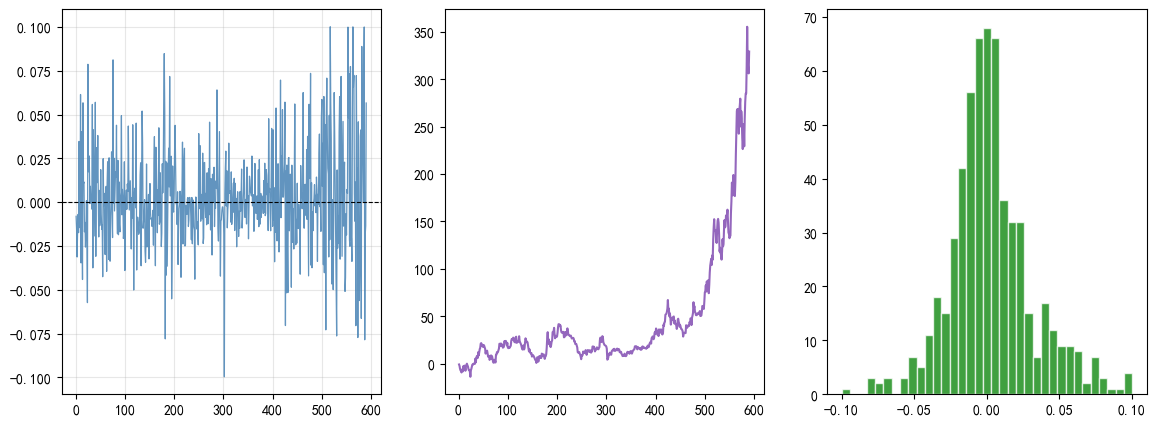

In [3]:
data  = get_a_stock_daily("600522","20240101","20260615", adjust="hfq")

df = data['close'].pct_change().dropna()
display(df)

rets = df
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
axes[0].plot(rets.index, rets.values, color='steelblue',linewidth=0.9, alpha=0.85)
axes[0].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[0].grid(True, alpha=0.3)

cum_return = (1 + rets).cumprod()-1
axes[1].plot(cum_return.index, cum_return.values*100, color='tab:purple', linewidth=1.5)

axes[2].hist(rets.values, bins=35, color='green', alpha=0.75, edgecolor='white')


In [4]:
# 3 移动平均线策略 
data  = get_a_stock_daily("600522","20240101","20260616", adjust="hfq")

df = data['close'].dropna().copy()
display(df)
df = data[['close']].dropna().copy()
df.columns=['close']
df['MA5'] = df['close'].rolling(5).mean()
df['MA20'] = df['close'].rolling(20).mean()
print('---------------------')
display(df)

  [新浪] sh600522: 592 天


0      107.50
1      106.63
2      104.98
3      101.69
4       99.96
        ...  
587    451.03
588    442.68
589    436.66
590    461.36
591    486.52
Name: close, Length: 592, dtype: float64

---------------------


,close,MA5,MA20
0,107.50,NaN,NaN
1,106.63,NaN,NaN
2,104.98,NaN,NaN
3,101.69,NaN,NaN
4,99.96,104.152,NaN
...,...,...,...
587,451.03,442.656,396.8750
588,442.68,448.426,399.1980
589,436.66,452.974,402.6170
590,461.36,456.244,405.9410


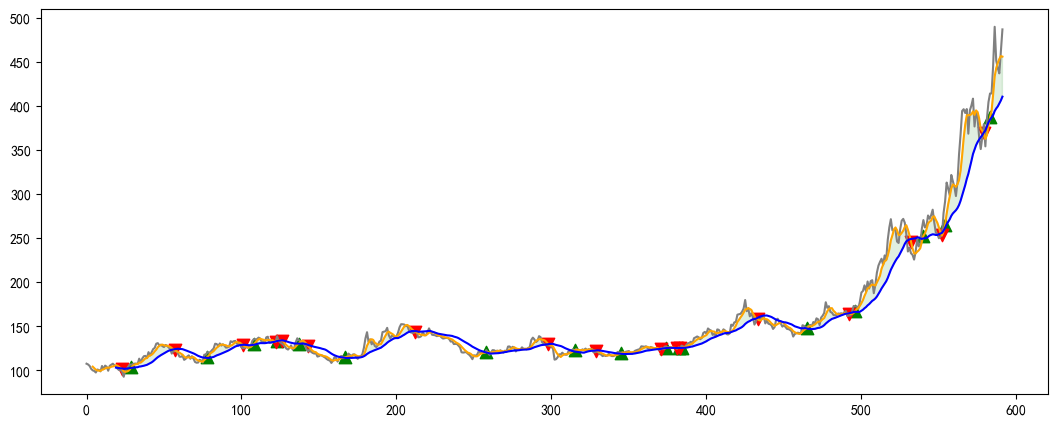

In [5]:

plt.figure(figsize=(13,5))
plt.plot(df.index, df['close'], color='gray')
plt.plot(df.index, df['MA5'], color='orange')
plt.plot(df.index, df['MA20'], color='blue')

df['spread']=df['MA5']-df['MA20']
df['cross'] = np.sign(df['spread']).diff()

golden=df[df['cross']==2].dropna(subset=['MA5','MA20'])
death=df[df['cross']==-2].dropna(subset=['MA5','MA20'])

plt.fill_between(df.index, df['MA5'], df['MA20'],
                where=(df['MA5'] >= df['MA20']),  
                interpolate=True, alpha=0.12, color='green', label='MA5 > MA20')
plt.scatter(golden.index, golden['MA5'], marker='^',s=80, color='green')
plt.scatter(death.index, death['MA5'], marker='v',s=80, color='red')


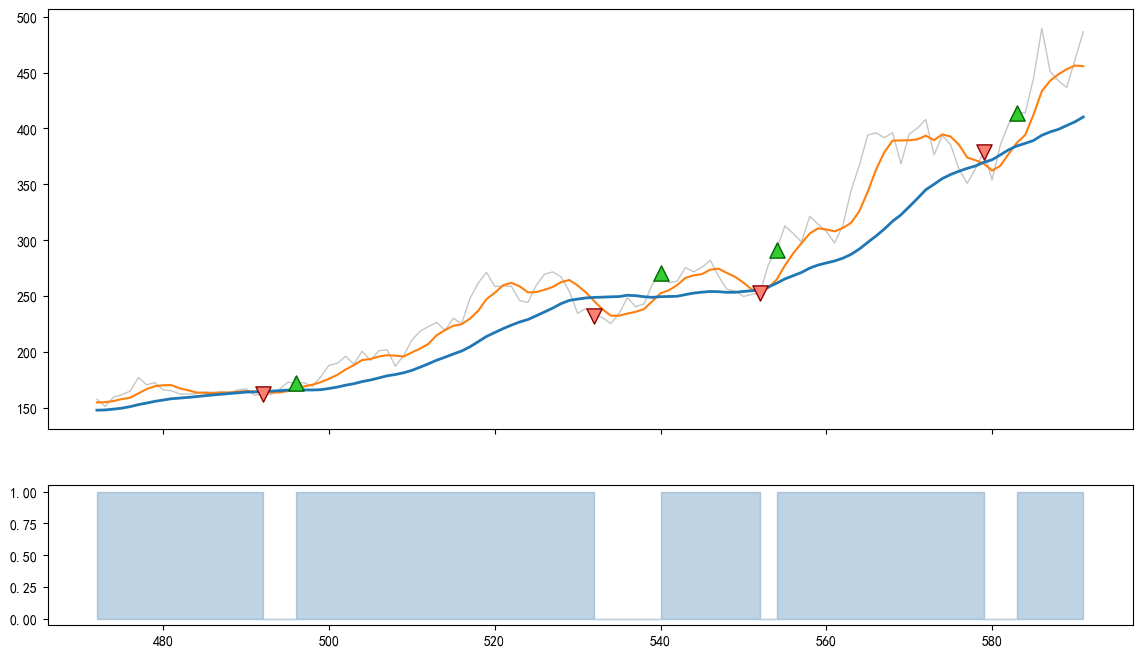

In [6]:
df['signal']=(df['MA5'] > df['MA20']).astype(int)
df['trade']=0
df.loc[df['cross']>0,'trade']=1
df.loc[df['cross'] < 0, 'trade']=-1

df = df.tail(120)
buys = df[df['trade'] == 1]
sells = df[df['trade'] == -1]

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True,
                         gridspec_kw={'height_ratios': [3, 1]})
ax_price, ax_pos = axes

ax_price.plot(df.index, df['close'], color='gray', alpha=0.45, linewidth=1, label='收盘价')
ax_price.plot(df.index, df['MA5'], color='tab:orange', linewidth=1.5, label='MA5')
ax_price.plot(df.index, df['MA20'], color='tab:blue', linewidth=2, label='MA20')

ax_price.scatter(buys.index, buys['close'], marker='^', s=120, color='limegreen',
                 edgecolors='darkgreen', linewidths=1, zorder=6, label='买入 ▲')
ax_price.scatter(sells.index, sells['close'], marker='v', s=120, color='salmon',
                 edgecolors='darkred', linewidths=1, zorder=6, label='卖出 ▼')

ax_pos.fill_between(df.index, 0, df['signal'], step='post', alpha=0.35, color='steelblue')

  [新浪] sh600522: 592 天
buy 18, sell 17


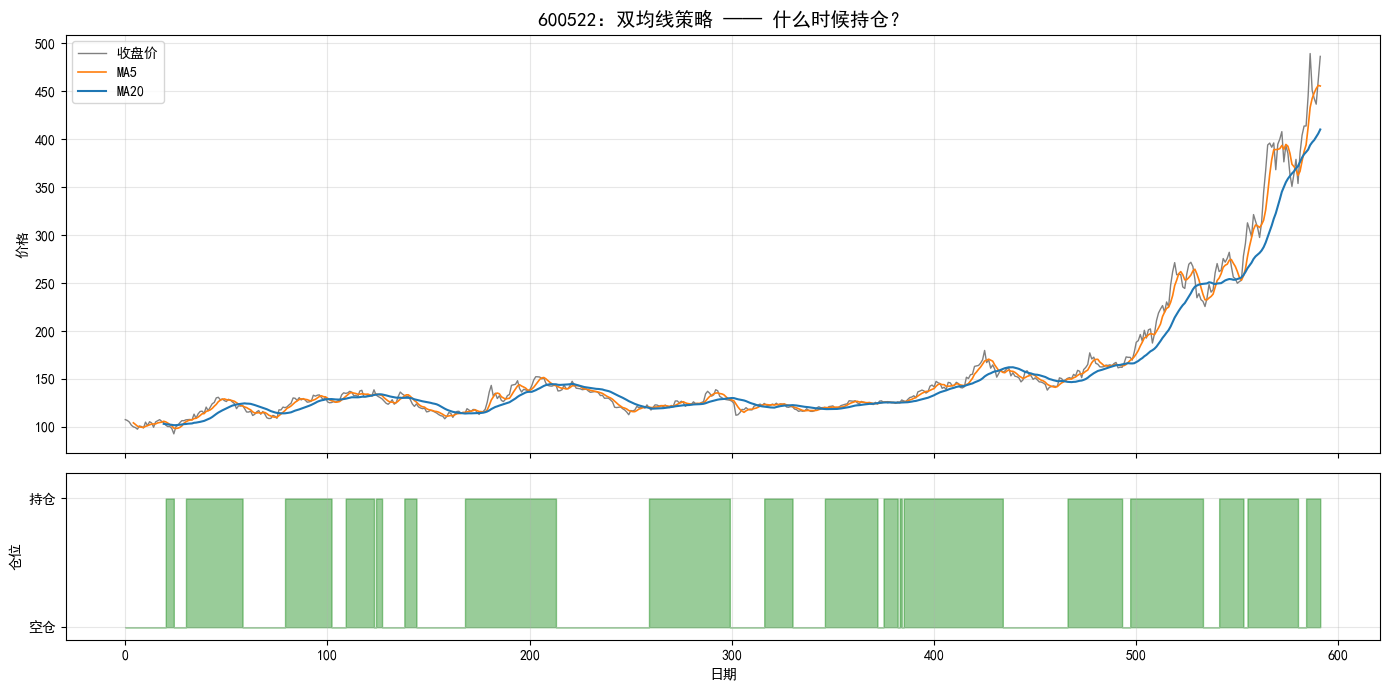

,close,MA5,MA20,signal,position,position_change,action,ret,strategy_ret,buy_hold_ret,nav_strategy,nav_buy_hold
0,107.50,NaN,NaN,0,0,0.0,,0.000000,0.000000,0.000000,1.000000,1.000000
1,106.63,NaN,NaN,0,0,0.0,,-0.008093,-0.000000,-0.008093,1.000000,0.991907
2,104.98,NaN,NaN,0,0,0.0,,-0.015474,-0.000000,-0.015474,1.000000,0.976558
3,101.69,NaN,NaN,0,0,0.0,,-0.031339,-0.000000,-0.031339,1.000000,0.945953
4,99.96,104.152,NaN,0,0,0.0,,-0.017012,-0.000000,-0.017012,1.000000,0.929860
...,...,...,...,...,...,...,...,...,...,...,...,...
587,451.03,442.656,396.8750,1,1,0.0,,-0.078572,-0.078572,-0.078572,2.952507,4.195628
588,442.68,448.426,399.1980,1,1,0.0,,-0.018513,-0.018513,-0.018513,2.897847,4.117953
589,436.66,452.974,402.6170,1,1,0.0,,-0.013599,-0.013599,-0.013599,2.858439,4.061953
590,461.36,456.244,405.9410,1,1,0.0,,0.056566,0.056566,0.056566,3.020129,4.291721


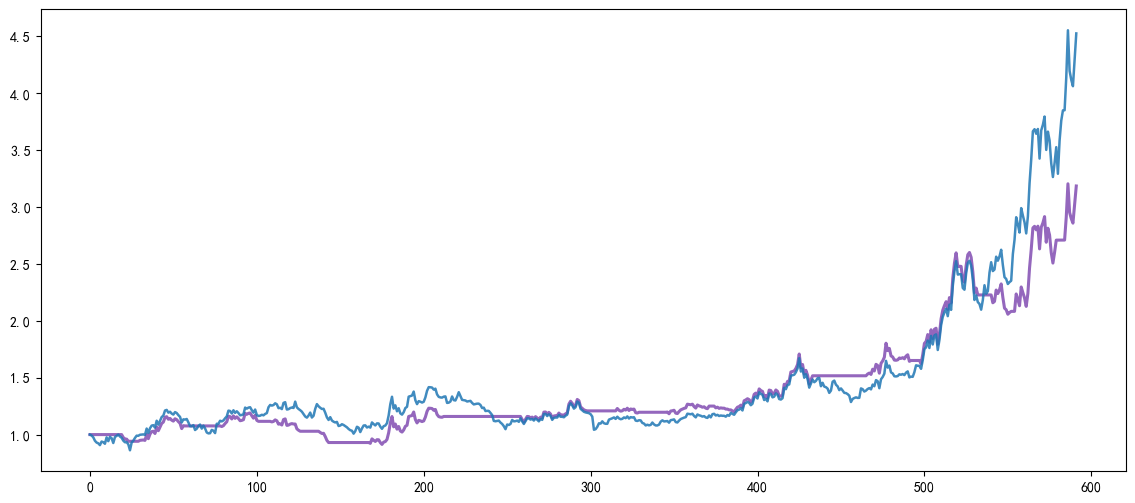

In [7]:
# 4 策略回测
TICKER = '600522'          
BENCHMARK = '399006'          # 创业板指数
PERIOD = '2y'                 # 回测样本长度

data  = get_a_stock_daily("600522","20240101","20260616", adjust="hfq")
df = data[['close']].dropna().copy()

df.columns = ['close']
df['MA5']=df['close'].rolling(5).mean()
df['MA20']=df['close'].rolling(20).mean()
df['signal']=(df['MA5']>df['MA20']).astype(int)

df['position']=df['signal'].shift(1).fillna(0).astype(int)

df['position_change']=df['position'].diff().fillna(0)
df['action']=''
df.loc[df['position_change']>0,'action']='buy'
df.loc[df['position_change']<0,'action']='sell'
print(f'buy {(df["action"]=="buy").sum()}, sell {(df["action"]=="sell").sum()}')

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True,
                         gridspec_kw={'height_ratios': [2.5, 1]})

axes[0].plot(df.index, df['close'], color='gray', linewidth=1, label='收盘价')
axes[0].plot(df.index, df['MA5'], color='tab:orange', linewidth=1.2, label='MA5')
axes[0].plot(df.index, df['MA20'], color='tab:blue', linewidth=1.5, label='MA20')
axes[0].set_ylabel('价格')
axes[0].set_title(f'{TICKER}：双均线策略 —— 什么时候持仓？', fontsize=14)
axes[0].legend(loc='upper left')
axes[0].grid(True, alpha=0.3)

axes[1].fill_between(df.index, 0, df['position'], step='post', alpha=0.4, color='green')
axes[1].set_ylim(-0.1, 1.2)
axes[1].set_yticks([0, 1])
axes[1].set_yticklabels(['空仓', '持仓'])
axes[1].set_xlabel('日期')
axes[1].set_ylabel('仓位')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

df['ret'] = df['close'].pct_change().fillna(0)
df['strategy_ret']=df['position']*df['ret']

df['buy_hold_ret']=df['ret']

df['nav_strategy']=(1+df['strategy_ret']).cumprod()
df['nav_buy_hold']=(1+df['buy_hold_ret']).cumprod()

display(df)
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(df.index, df['nav_strategy'], linewidth=2.2, color='tab:purple',
        label=f'双均线策略 ({TICKER})')
ax.plot(df.index, df['nav_buy_hold'], linewidth=1.8, color='tab:blue', alpha=0.85,
        label=f'买入持有 ({TICKER})')

